# Chronos-2: SHAPformer e ANEEL

This notebook is self-contained and writes no result files. It forecasts the SHAPformer synthetic electricity mechanism (168→168 hours) and ANEEL SAMP national monthly `Energia TUSD (kWh)` (2010–2024→2025). Only target history is supplied. Seed: **42**. Figures and metrics remain in this notebook.

Sources: [SHAPformer](https://doi.org/10.1038/s41467-026-73243-5), [ANEEL SAMP](https://dadosabertos.aneel.gov.br/dataset/3e153db4-a503-4093-88be-75d31b002dcf).

Python 3.11; install `chronos-forecasting pandas pyarrow matplotlib`.

In [1]:
from __future__ import annotations
import io, json, platform, random, sys, time, urllib.request
from dataclasses import dataclass
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SEED = 42
ANEEL_API = "https://dadosabertos.aneel.gov.br/api/3/action/package_show?id=samp"

@dataclass(frozen=True)
class ForecastCase:
    name: str
    context_time: pd.DatetimeIndex
    context: np.ndarray
    future_time: pd.DatetimeIndex
    future: np.ndarray
    seasonal_period: int

class ShapformerElectricityGenerator:
    """Exact NumPy transcription of SHAPformer's ExogenousDataGenerator."""
    def __init__(self, noise=0.05): self.noise = noise
    @staticmethod
    def _base_day_load():
        x = np.arange(24) * 2 * np.pi / 24
        return np.sin(x - 0.5 * np.pi)
    def _sample_day(self):
        factor = np.random.uniform(0.5, 1.0)
        alpha = np.random.uniform(-0.5, 0.5)
        beta = np.random.uniform(-0.5, 0.5)
        x = np.arange(24) * 2 * np.pi / 24
        return (self._base_day_load() + alpha * np.sin(x) + beta * np.cos(x)) * factor
    @staticmethod
    def _add_noise(x, level): return x + np.random.normal(0, level, size=x.shape)
    @staticmethod
    def _generate_temperature():
        return np.random.uniform() + np.cumsum(np.random.normal(0, 0.02, size=336))
    def _generate_load(self, start_hour, start_day, month):
        base = np.random.uniform(-0.5, 0.5) + 0.1 * np.sin(month * 2 * np.pi / 12)
        normal = base + self._add_noise(self._sample_day(), 0.1)
        saturday_factor = np.random.uniform(0.5, 0.9)
        special_factor = np.random.uniform(0.2, saturday_factor)
        saturday = self._add_noise(saturday_factor * normal, 0.1)
        special = self._add_noise(special_factor * normal, 0.1)
        load, holidays = np.zeros(336), np.zeros(336, dtype=int)
        hour, day, holiday = start_hour, start_day, np.random.uniform() < 0.1
        for i in range(336):
            if hour == 24:
                hour, holiday, day = 0, np.random.uniform() < 0.1, (day + 1) % 7
            holidays[i] = int(holiday)
            load[i] = special[hour] if day == 6 or holiday else saturday[hour] if day == 5 else normal[hour]
            hour += 1
        return load
    def generate(self):
        start_hour, start_day, month = np.random.randint(0, 24), np.random.randint(0, 7), np.random.randint(0, 12)
        load = self._generate_load(start_hour, start_day, month)
        load *= 0.5 + 0.5 * self._generate_temperature()
        load += self._add_noise(np.zeros_like(load), self.noise)
        return load[:168], load[168:]

def shapformer_case():
    random.seed(SEED); np.random.seed(SEED)
    context, future = ShapformerElectricityGenerator().generate()
    timestamps = pd.date_range("2025-01-06", periods=336, freq="h")
    return ForecastCase("SHAPformer sintético", timestamps[:168], context, timestamps[168:], future, 24)

def aneel_case():
    """Download into memory and aggregate national Energia TUSD from SAMP."""
    request = urllib.request.Request(ANEEL_API, headers={"User-Agent": "tsfmxai/0.0.0"})
    with urllib.request.urlopen(request, timeout=60) as response:
        package = json.load(response)["result"]
    resources = {item["name"]: item["url"] for item in package["resources"]}
    parts = []
    for year in range(2010, 2026):
        request = urllib.request.Request(resources[f"samp-{year}.parquet"], headers={"User-Agent": "tsfmxai/0.0.0"})
        with urllib.request.urlopen(request, timeout=180) as response: payload = response.read()
        frame = pd.read_parquet(io.BytesIO(payload), columns=["DatCompetencia", "DscDetalheMercado", "VlrMercado"])
        selected = frame.loc[frame["DscDetalheMercado"].eq("Energia TUSD (kWh)")]
        parts.append(selected.groupby("DatCompetencia", as_index=False)["VlrMercado"].sum())
    monthly = pd.concat(parts, ignore_index=True)
    monthly["timestamp"] = pd.to_datetime(monthly["DatCompetencia"])
    monthly["consumption_twh"] = monthly["VlrMercado"] / 1e9
    monthly = monthly.sort_values("timestamp")
    expected = pd.date_range("2010-01-01", "2025-12-01", freq="MS")
    assert monthly["timestamp"].reset_index(drop=True).equals(pd.Series(expected, name="timestamp"))
    train, test = monthly[monthly["timestamp"] < "2025-01-01"], monthly[monthly["timestamp"] >= "2025-01-01"]
    return ForecastCase("ANEEL Brasil — Energia TUSD", pd.DatetimeIndex(train["timestamp"]), train["consumption_twh"].to_numpy(), pd.DatetimeIndex(test["timestamp"]), test["consumption_twh"].to_numpy(), 12)

def metrics(case, prediction):
    prediction, actual = np.asarray(prediction, dtype=float).reshape(-1), case.future
    assert prediction.shape == actual.shape and np.isfinite(prediction).all()
    error = prediction - actual
    scale = np.mean(np.abs(case.context[case.seasonal_period:] - case.context[:-case.seasonal_period]))
    denominator = np.abs(actual) + np.abs(prediction)
    smape = np.divide(2*np.abs(error), denominator, out=np.zeros_like(error), where=denominator > 0)
    return {"MAE": np.mean(np.abs(error)), "RMSE": np.sqrt(np.mean(error**2)), "sMAPE (%)": 100*np.mean(smape), "MASE": np.mean(np.abs(error))/scale}

def show_forecast(model_name, case, prediction, lower=None, upper=None):
    tail = min(len(case.context), 2*len(case.future))
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(case.context_time[-tail:], case.context[-tail:], label="contexto")
    ax.plot(case.future_time, case.future, color="black", linewidth=2, label="observado")
    ax.plot(case.future_time, prediction, color="#E45756", linewidth=2, label="previsão")
    if lower is not None: ax.fill_between(case.future_time, lower, upper, color="#E45756", alpha=.18, label="10–90%")
    ax.axvline(case.future_time[0], color=".5", linestyle="--")
    ax.set(title=f"{model_name} — {case.name}", ylabel="TWh" if "ANEEL" in case.name else "carga normalizada")
    ax.grid(alpha=.2); ax.legend(frameon=False, ncol=4); plt.show()

def evaluate(model_name, forecast):
    rows = []
    for case in (shapformer_case(), aneel_case()):
        started = time.perf_counter(); prediction, lower, upper = forecast(case); elapsed = time.perf_counter()-started
        show_forecast(model_name, case, prediction, lower, upper)
        rows.append({"dataset": case.name, **metrics(case, prediction), "tempo (s)": elapsed})
    return pd.DataFrame(rows).set_index("dataset")


In [2]:
from chronos import Chronos2Pipeline
model=Chronos2Pipeline.from_pretrained("amazon/chronos-2",device_map="cpu")
def forecast(case):
    frame=pd.DataFrame({"id":case.name,"timestamp":case.context_time,"target":case.context})
    out=model.predict_df(frame,prediction_length=len(case.future),quantile_levels=[.1,.5,.9],id_column="id",timestamp_column="timestamp",target="target")
    return out["0.5"].to_numpy(),out["0.1"].to_numpy(),out["0.9"].to_numpy()


C:\Users\mateu\repos\tsfmxai\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


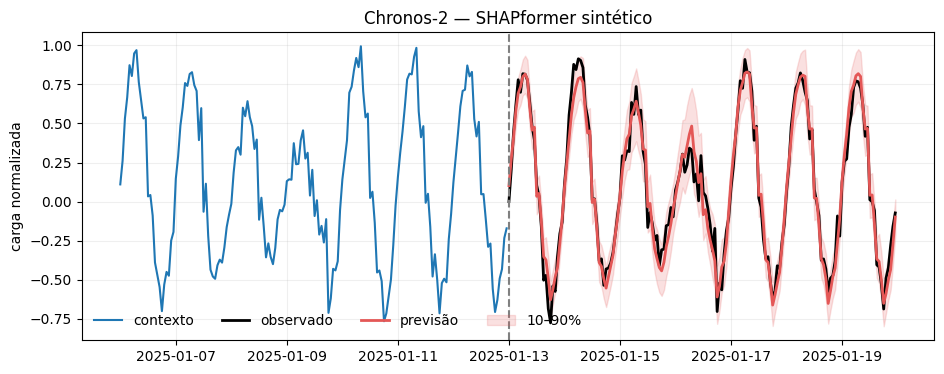

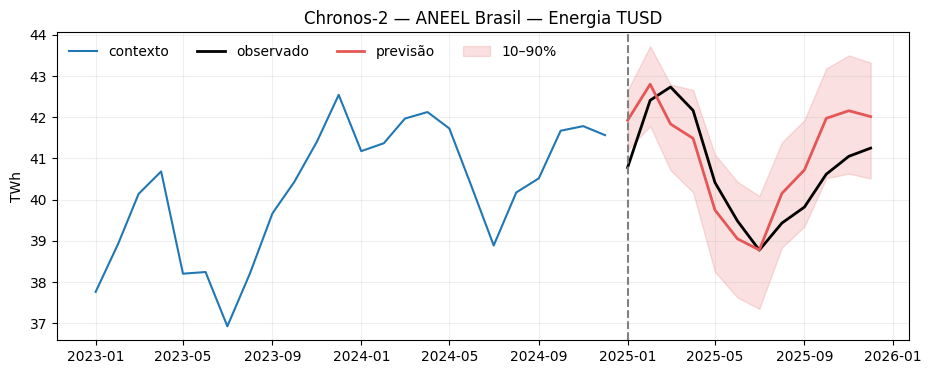

,MAE,RMSE,sMAPE (%),MASE,tempo (s)
dataset,,,,,
SHAPformer sintético,0.063819,0.080284,32.602683,0.470483,0.240869
ANEEL Brasil — Energia TUSD,0.755029,0.833229,1.835561,0.693621,0.108194


In [3]:
results=evaluate("Chronos-2",forecast)
results

In [4]:
print({"python":sys.version.split()[0],"platform":platform.platform()})

{'python': '3.11.9', 'platform': 'Windows-10-10.0.19045-SP0'}
